In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('titanic_train.csv',usecols=['Age','Fare','Survived'])

In [6]:
df.dropna(inplace=True)

In [8]:
df.shape

(714, 3)

In [10]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [11]:
X_train,  X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [15]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [16]:
pred=clf.predict(X_test)

In [20]:
print("Accuracy Raw:",round(accuracy_score(pred,y_test)*100,2),"%")

Accuracy Raw: 62.24 %


In [21]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [26]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
],remainder='passthrough')

In [27]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.fit_transform(X_test)

In [29]:
print(trf.named_transformers_['first'].bin_edges_)
print(trf.named_transformers_['second'].bin_edges_)

[array([ 1.        ,  9.        , 15.9       , 17.        , 20.        ,
        21.        , 24.        , 26.        , 28.        , 30.1       ,
        33.66666667, 36.        , 38.6       , 44.06666667, 52.        ,
        62.        ])                                                   ]
[array([  0.        ,   7.17166667,   7.77333333,   7.925     ,
          8.05      ,   9.5       ,  10.5       ,  13.        ,
         17.69333333,  22.62      ,  26.35276667,  31.275     ,
         38.1       ,  53.22666667,  79.27666667, 512.3292    ])]


In [30]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [31]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [32]:

output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
786,18.0,2.0,7.4958,1.0,"(17.0, 20.0]","(7.172, 7.773]"
503,37.0,10.0,9.5875,4.0,"(36.0, 38.6]","(9.5, 10.5]"
142,24.0,5.0,15.8500,7.0,"(21.0, 24.0]","(13.0, 17.693]"
114,17.0,2.0,14.4583,7.0,"(15.9, 17.0]","(13.0, 17.693]"
439,31.0,8.0,10.5000,5.0,"(30.1, 33.667]","(9.5, 10.5]"


In [33]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [34]:
accuracy_score(y_test,y_pred2)

0.6503496503496503

In [35]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6261150234741784

In [36]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

C:\Users\umair\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
C:\Users\umair\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\umair\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
C:\Users\umair\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMean

0.6303012519561815


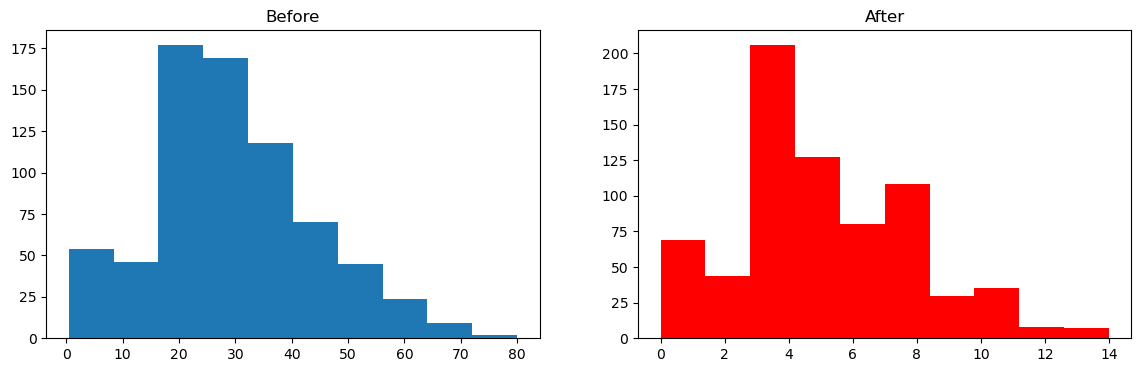

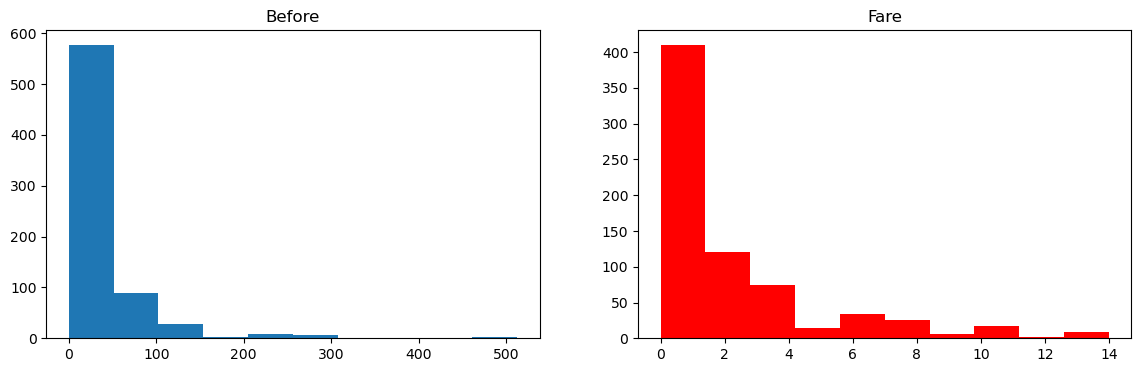

In [37]:
discretize(15,'kmeans')